In [ ]:
# setting up kaggle and loading the data
# two files: transactions (what was bought) and identity (device/browser info)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-upload kaggle.json
from google.colab import files
files.upload()  # upload kaggle.json when prompted

# Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download data
!kaggle competitions download -c ieee-fraud-detection
!unzip -o ieee-fraud-detection.zip -d /content/data/

# Load data
trans = pd.read_csv('/content/data/train_transaction.csv')
identity = pd.read_csv('/content/data/train_identity.csv')

print("Everything loaded successfully")
print("Transaction shape:", trans.shape)
print("Identity shape:", identity.shape)


Saving kaggle.json to kaggle.json
  0% 0.00/118M [00:00<?, ?B/s]
100% 118M/118M [00:00<00:00, 1.40GB/s]
Archive:  ieee-fraud-detection.zip
  inflating: /content/data/sample_submission.csv  
  inflating: /content/data/test_identity.csv  
  inflating: /content/data/test_transaction.csv  
  inflating: /content/data/train_identity.csv  
  inflating: /content/data/train_transaction.csv  
Everything loaded successfully
Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [ ]:
# first thing to check - how much fraud is actually in the dataset
print("Fraud rate:")
print(trans['isFraud'].value_counts())
print("\nAs percentage:")
print(trans['isFraud'].value_counts(normalize=True) * 100)

Fraud rate:
isFraud
0    569877
1     20663
Name: count, dtype: int64

As percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [ ]:
# checking how much data is missing
# some columns are 90%+ missing which means they're useless
print("Missing values in transaction data (top 20):")
print(trans.isnull().sum().sort_values(ascending=False).head(20))

Missing values in transaction data (top 20):
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
dtype: int64


In [ ]:
# just looking at what columns we have
print(trans.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [ ]:
# basic stats on the important columns - amounts, product types, card types
print(trans[['TransactionAmt', 'ProductCD', 'card4', 'card6']].describe())
print("\nProductCD values:", trans['ProductCD'].value_counts())
print("Card4 values:", trans['card4'].value_counts())
print("Card6 values:", trans['card6'].value_counts())

       TransactionAmt
count   590540.000000
mean       135.027176
std        239.162522
min          0.251000
25%         43.321000
50%         68.769000
75%        125.000000
max      31937.391000

ProductCD values: ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64
Card4 values: card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64
Card6 values: card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64


In [ ]:
# which product types and card types have the highest fraud rates?
# product C (digital goods) is way higher than others - makes sense, easier to steal digitally
import matplotlib.pyplot as plt

# Fraud rate by ProductCD
product_fraud = trans.groupby('ProductCD')['isFraud'].mean() * 100
print("Fraud rate by Product:")
print(product_fraud.sort_values(ascending=False))

# Fraud rate by card type
card_fraud = trans.groupby('card6')['isFraud'].mean() * 100
print("\nFraud rate by Card Type:")
print(card_fraud.sort_values(ascending=False))

# Fraud rate by card network
network_fraud = trans.groupby('card4')['isFraud'].mean() * 100
print("\nFraud rate by Card Network:")
print(network_fraud.sort_values(ascending=False))

Fraud rate by Product:
ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64

Fraud rate by Card Type:
card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

Fraud rate by Card Network:
card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64


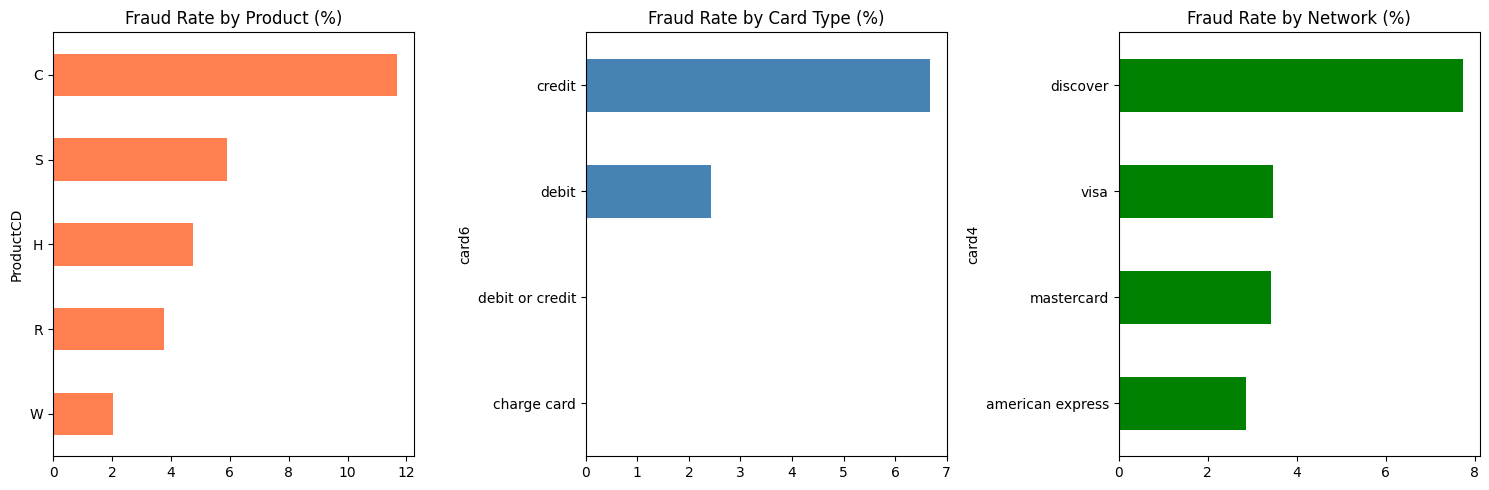

In [ ]:
# visualizing the fraud rates from above
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

product_fraud.sort_values().plot(kind='barh', ax=axes[0],
    color='coral', title='Fraud Rate by Product (%)')

card_fraud.sort_values().plot(kind='barh', ax=axes[1],
    color='steelblue', title='Fraud Rate by Card Type (%)')

network_fraud.sort_values().plot(kind='barh', ax=axes[2],
    color='green', title='Fraud Rate by Network (%)')

plt.tight_layout()
plt.savefig('fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

Legitimate transactions:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Fraud transactions:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


/tmp/ipython-input-208/927266721.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amt_fraud = trans.groupby('AmtBucket')['isFraud'].mean() * 100


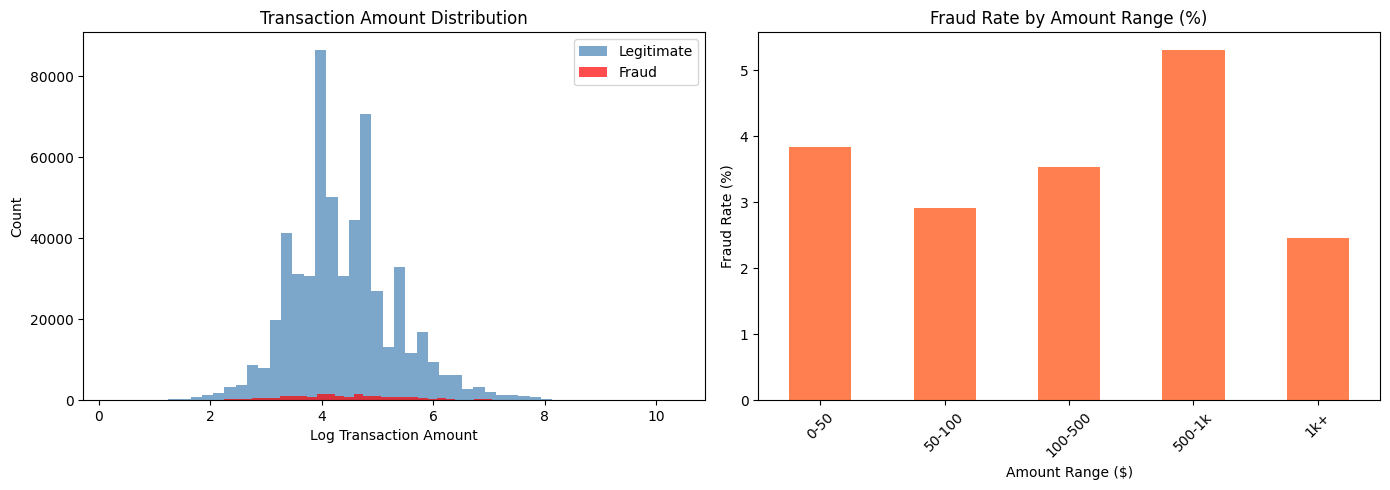

In [ ]:
# do fraudsters spend differently than normal customers?
# using log scale because amounts range from $0.25 to $32k - otherwise the chart is unreadable
import numpy as np

# Compare transaction amounts fraud vs legitimate
fraud = trans[trans['isFraud'] == 1]['TransactionAmt']
legit = trans[trans['isFraud'] == 0]['TransactionAmt']

print("Legitimate transactions:")
print(legit.describe())
print("\nFraud transactions:")
print(fraud.describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale histogram - we use log because amounts are very skewed
axes[0].hist(np.log1p(legit), bins=50, alpha=0.7,
             color='steelblue', label='Legitimate')
axes[0].hist(np.log1p(fraud), bins=50, alpha=0.7,
             color='red', label='Fraud')
axes[0].set_xlabel('Log Transaction Amount')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()

# Fraud rate by amount buckets
trans['AmtBucket'] = pd.cut(trans['TransactionAmt'],
                             bins=[0,50,100,500,1000,32000],
                             labels=['0-50','50-100',
                                    '100-500','500-1k','1k+'])
amt_fraud = trans.groupby('AmtBucket')['isFraud'].mean() * 100
amt_fraud.plot(kind='bar', ax=axes[1], color='coral',
               title='Fraud Rate by Amount Range (%)')
axes[1].set_xlabel('Amount Range ($)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

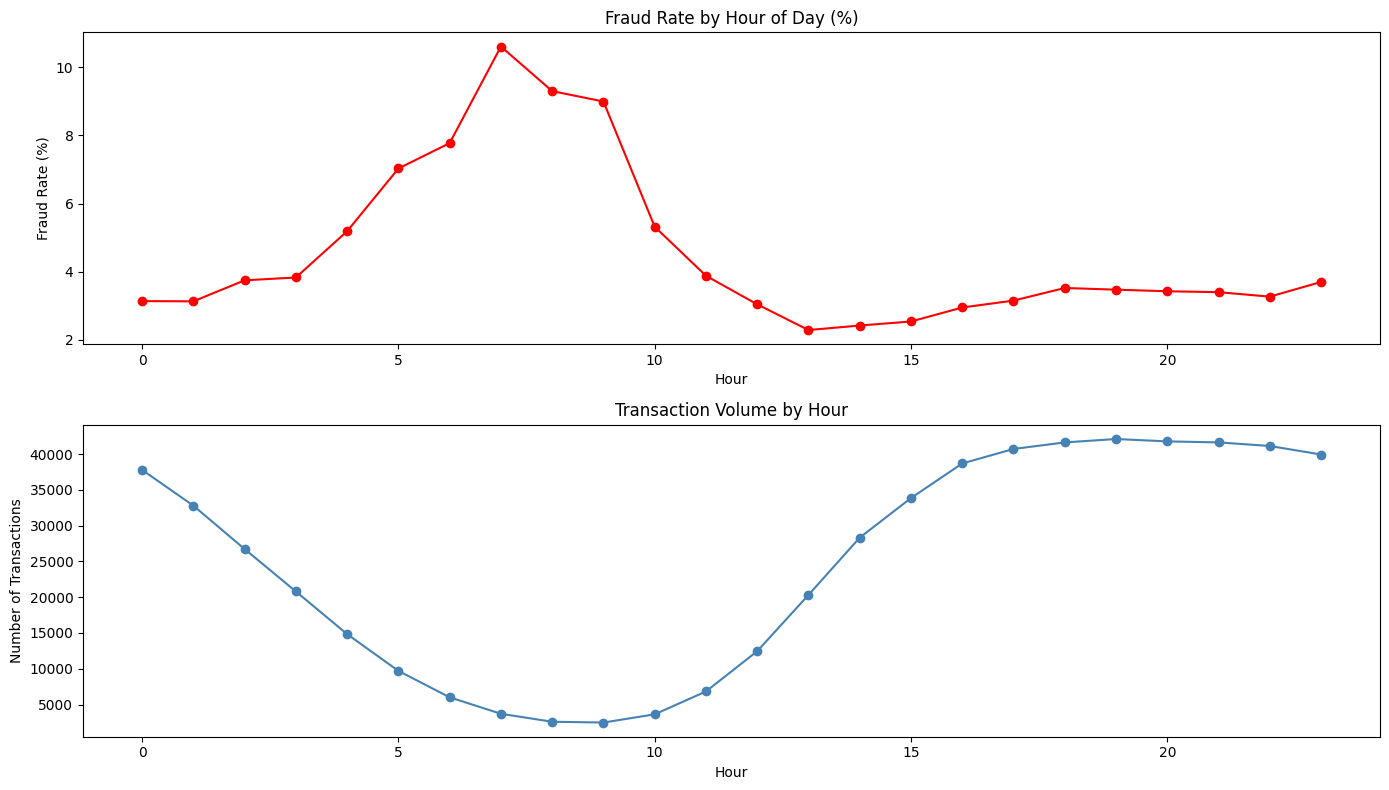

In [ ]:
# TransactionDT is seconds since a reference point
# Let's extract hour of day pattern
trans['hour'] = (trans['TransactionDT'] // 3600) % 24

hour_fraud = trans.groupby('hour')['isFraud'].mean() * 100
hour_count = trans.groupby('hour')['isFraud'].count()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

hour_fraud.plot(ax=axes[0], color='red', marker='o',
               title='Fraud Rate by Hour of Day (%)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Hour')

hour_count.plot(ax=axes[1], color='steelblue', marker='o',
               title='Transaction Volume by Hour')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# looking at the identity table - device type, browser, screen size etc
identity = pd.read_csv('/content/data/train_identity.csv')

print("Identity columns:")
print(identity.columns.tolist())

print("\nSample data:")
print(identity.head())

print("\nMissing values (top 10):")
print(identity.isnull().sum().sort_values(ascending=False).head(10))

Identity columns:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Sample data:
   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung bro

In [ ]:
# How many transactions have identity data?
trans_with_identity = trans[trans['TransactionID'].isin(identity['TransactionID'])]
print("Transactions WITH identity data:", len(trans_with_identity))
print("Transactions WITHOUT identity data:", len(trans) - len(trans_with_identity))

# Fraud rate with vs without identity
fraud_with = trans_with_identity['isFraud'].mean() * 100
fraud_without = trans[~trans['TransactionID'].isin(identity['TransactionID'])]['isFraud'].mean() * 100

print(f"\nFraud rate WITH identity data: {fraud_with:.2f}%")
print(f"Fraud rate WITHOUT identity data: {fraud_without:.2f}%")

# Device type fraud rate
merged = trans.merge(identity[['TransactionID', 'DeviceType', 'DeviceInfo']],
                     on='TransactionID', how='left')
print("\nFraud rate by Device Type:")
print(merged.groupby('DeviceType')['isFraud'].mean() * 100)

Transactions WITH identity data: 144233
Transactions WITHOUT identity data: 446307

Fraud rate WITH identity data: 7.85%
Fraud rate WITHOUT identity data: 2.09%

Fraud rate by Device Type:
DeviceType
desktop     6.521458
mobile     10.166232
Name: isFraud, dtype: float64


Day 1 — Data Exploration

We are working with a real world payment dataset of 590,540 transactions
across 394 features. The data is split into two files, transactions and
identity, linked by TransactionID. Only 144,233 transactions (about 25%)
have identity data attached. For the remaining 75% we know nothing about
the device, browser, or person behind the payment.

The fraud rate is 3.5%, only 20,663 fraud cases hiding among 569,877
legitimate ones. That sounds low but it is the whole problem. A model
that just predicts "not fraud" every time gets 96.5% accuracy while
catching zero actual fraud. So accuracy is meaningless here, we need
precision and recall.

Patterns that stood out after exploring the data:

Product C has a striking 11.7% fraud rate, nearly 3x the overall average.
Digital goods are easier to monetize quickly so that makes sense.

Fraud peaks at hour 8 with 10.5% rate but the lowest transaction volume
of the day. Fraudsters clearly prefer to operate when monitoring is
minimal and cardholders are asleep.

Mobile transactions are riskier at 10.2% fraud vs 6.5% on desktop.
Credit cards see more fraud at 6.7% compared to debit cards at 2.4%.

The $500 to $1000 range has the highest fraud rate, suggesting fraudsters
deliberately stay under high value alert thresholds to avoid automatic review.

Transactions with identity data have 7.85% fraud rate vs just 2.09%
without, because identity data is mostly captured on online purchases
where card not present fraud is most common.

The class imbalance means we need SMOTE and cost sensitive learning to
stop the model from being lazy. We will optimize for precision and recall
instead of accuracy. The heavy missing data in identity features means
the model must be robust enough to work without them for most transactions.

All the signals found today, time patterns, amount buckets, device type,
product category, feed into feature engineering starting Day 2.